# Détection d'intrusion réseau (NIDS) par Machine Learning

**Aperçu :** Ce notebook présente une approche de détection d'intrusions réseau (Network Intrusion Detection System - NIDS) fondée sur des méthodes d'apprentissage automatique. L'objectif est d'illustrer le processus complet — depuis le chargement et l'exploration des données, en passant par le prétraitement, la sélection de modèles et l'évaluation — jusqu'à l'interprétation des résultats et les perspectives d'amélioration.

**Structure du notebook :**  
1. Introduction  
2. Chargement et exploration des données  
3. Prétraitement et préparation des variables  
4. Modélisation (algorithmes de Machine Learning)  
5. Évaluation et interprétation des résultats  
6. Conclusion et perspectives




In [77]:
# --- 1. Imports des Bibliothèques Essentielles ---
import pandas as pd
import numpy as np # Utile pour les opérations numériques (NaN, infini)
import time # Pour chronométrer certaines opérations

## 1. Chargement & Exploration Initiale des Données (EDA)

Chargement du fichier CSV dans un DataFrame Pandas et première inspection pour comprendre la structure, les types de données et la taille.

In [78]:
# --- 2. Configuration Initiale ---
# Chemin vers le fichier CSV contenant les données réseau
# Note: Ce fichier contient uniquement les données du 14/02/2018
file_path = '/content/02-14-2018.csv'

In [79]:
print(f"Tentative de chargement du fichier : {file_path}...")
try:
    # Chargement du fichier CSV en DataFrame
    df = pd.read_csv(file_path)
    print("Dataset chargé avec succès !")

except FileNotFoundError:
    print(f"ERREUR : Fichier non trouvé à {file_path}. Vérifiez le nom et l'emplacement.")
except Exception as e:
    # Gestion des erreurs potentielles (ex: mémoire insuffisante)
    print(f"Une erreur est survenue lors du chargement : {e}")
    print("Conseil : Si le fichier est trop volumineux, essayez avec l'option 'nrows' :")
    print(f"df = pd.read_csv(file_path, nrows=100000)")

Tentative de chargement du fichier : /content/02-14-2018.csv...
Dataset chargé avec succès !


### 1.1 Inspection de Base

Affichage des dimensions, des premières lignes et des types de colonnes pour avoir un aperçu rapide du contenu.

In [80]:
# Afficher les dimensions (lignes, colonnes)
print(f"\nDimensions du DataFrame (lignes, colonnes): {df.shape}")

# Afficher les 5 premières lignes pour visualiser les données
print("\nAperçu des 5 premières lignes :")
# display() offre un meilleur rendu que print() dans Colab pour les DataFrames
display(df.head())

# Afficher un résumé des colonnes, types et valeurs non nulles
print("\nRésumé des colonnes (noms, types, non-nulls) :")
# verbose=False pour un résumé concis (évite d'afficher les 80 colonnes)
df.info(verbose=False)


Dimensions du DataFrame (lignes, colonnes): (1048575, 80)

Aperçu des 5 premières lignes :


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign



Résumé des colonnes (noms, types, non-nulls) :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Columns: 80 entries, Dst Port to Label
dtypes: float64(24), int64(54), object(2)
memory usage: 640.0+ MB


## 2. Nettoyage et Analyse Exploratoire Approfondie

Identification et traitement des données problématiques (NaN, Infinis) et analyse de la distribution de la variable cible.

In [81]:
# --- 2.1 Vérification des Valeurs Manquantes (NaN) ---
if 'df' in locals():
    print("--- Vérification des Valeurs Manquantes (NaN) ---")
    # Compte les NaN par colonne
    missing_values = df.isnull().sum()
    print("Colonnes contenant des valeurs manquantes (NaN) :")
    # Filtre pour n'afficher que les colonnes avec au moins un NaN
    print(missing_values[missing_values > 0])
    print(f"\nTotal de valeurs manquantes : {missing_values.sum()}")
else:
    print("Erreur : DataFrame 'df' non chargé.")

--- Vérification des Valeurs Manquantes (NaN) ---
Colonnes contenant des valeurs manquantes (NaN) :
Flow Byts/s    2277
dtype: int64

Total de valeurs manquantes : 2277


In [82]:
# --- 2.2 Vérification des Valeurs Infinies (inf / -inf) ---
if 'df' in locals():
    print("\n--- Vérification des Valeurs Infinies (inf) ---")
    # Crée une copie temporaire où les infinis sont remplacés par NaN
    df_no_inf = df.replace([np.inf, -np.inf], np.nan)
    # Compte tous les NaN dans cette copie
    infinite_values = df_no_inf.isnull().sum()
    # La différence avec le compte NaN initial donne le nombre d'infinis
    infinite_count = infinite_values - missing_values
    print("Colonnes contenant des valeurs infinies :")
    # Affiche seulement les colonnes concernées
    print(infinite_count[infinite_count > 0])
    print(f"\nTotal de valeurs infinies : {infinite_count.sum()}")
else:
    print("Erreur : DataFrame 'df' non chargé.")
# Note: La présence de NaN et Inf est fréquente dans les features calculées
# (ex: Flow Byts/s) en cas de division par zéro (Flow Duration = 0).


--- Vérification des Valeurs Infinies (inf) ---
Colonnes contenant des valeurs infinies :
Flow Byts/s    1547
Flow Pkts/s    3824
dtype: int64

Total de valeurs infinies : 5371


### 2.3 Configuration et Analyse de la Cible

In [83]:
# --- Configuration : Nom de la Colonne Cible ---
# Modifier la valeur ci-dessous si nécessaire
label_column_to_analyze = 'Label'
# --- Fin de la Configuration ---

print(f"Colonne cible sélectionnée pour l'analyse : '{label_column_to_analyze}'")

Colonne cible sélectionnée pour l'analyse : 'Label'


In [84]:
# --- Exécution de l'Analyse de Distribution ---

if 'df' in locals():
    # On utilise la variable définie dans la section précédente
    if label_column_to_analyze in df.columns:
        print(f"--- Vérification de la Distribution pour la colonne '{label_column_to_analyze}' ---")

        print("\nComptage des valeurs :")
        # Affiche le nombre d'occurrences pour chaque label unique
        value_counts_result = df[label_column_to_analyze].value_counts()
        print(value_counts_result)

        print("\nPourcentages :")
        # Affiche les pourcentages pour chaque label unique
        percentage_result = df[label_column_to_analyze].value_counts(normalize=True) * 100
        print(percentage_result)


    else:
        print(f"Erreur : La colonne '{label_column_to_analyze}' configurée n'a pas été trouvée dans le DataFrame.")
else:
    print("Erreur : Le DataFrame 'df' n'est pas chargé. Exécutez les cellules précédentes.")

# --- Fin de l'Analyse ---

--- Vérification de la Distribution pour la colonne 'Label' ---

Comptage des valeurs :
Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64

Pourcentages :
Label
Benign            63.669838
FTP-BruteForce    18.440264
SSH-Bruteforce    17.889898
Name: proportion, dtype: float64


## 3. Prétraitement et préparation des variables

Ici, les opérations de nettoyage et de transformation des variables sont appliquées : traitement des valeurs manquantes, encodage des variables catégorielles, normalisation/standardisation des caractéristiques, et tout autre traitement nécessaire avant l'entraînement des modèles.

In [85]:
if 'df' in locals():
    print("--- Remplacement des NaN et Valeurs Infinies par 0 ---")
    print(f"Shape avant nettoyage: {df.shape}")

    # Étape 1: Remplacer tous les infinis (positifs et négatifs) par NaN
    # Cela permet de traiter NaN et Inf en une seule étape (fillna)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Compte total des valeurs à remplacer (NaN d'origine + ex-infinis)
    nan_count_before_fill = df.isnull().sum().sum()
    print(f"Nombre total de cellules à remplir (NaN + Inf) : {nan_count_before_fill}")

    # Étape 2: Remplacer tous les NaN restants par 0
    df.fillna(0, inplace=True)

    # Vérification finale pour confirmer le nettoyage
    nan_count_after = df.isnull().sum().sum()
    # Re-vérifie les infinis juste au cas où (devrait être 0)
    inf_count_after = np.isinf(df.select_dtypes(include=np.number)).sum().sum()

    print(f"\nNombre de NaN après remplissage : {nan_count_after}")
    print(f"Nombre d'infinis restants : {inf_count_after}")

    if nan_count_after == 0 and inf_count_after == 0:
        print("\nNettoyage réussi.")
    else:
        print("\nAvertissement : Le nettoyage pourrait être incomplet.")

    print(f"Shape après nettoyage (inchangé): {df.shape}")

else:
    print("Erreur : DataFrame 'df' non chargé.")

--- Remplacement des NaN et Valeurs Infinies par 0 ---
Shape avant nettoyage: (1048575, 80)
Nombre total de cellules à remplir (NaN + Inf) : 7648

Nombre de NaN après remplissage : 0
Nombre d'infinis restants : 0

Nettoyage réussi.
Shape après nettoyage (inchangé): (1048575, 80)


## 3. Préparation des Données (Preprocessing)

Préparation des données pour l'entraînement : sélection des features (X), isolation de la cible (y), encodage, et division en ensembles d'entraînement/test.

### 3.1 Sélection des Features (X) et de la Cible (y)

Séparation du DataFrame nettoyé en deux :
- **X** : Les caractéristiques (features) utilisées pour l'entraînement (toutes les colonnes sauf la cible et 'Timestamp').
- **y_texte** : La variable cible textuelle ('Label').

In [86]:
if 'df' in locals():
    # On vérifie que la variable cible a bien été définie
    if 'label_column_to_analyze' not in locals() or label_column_to_analyze is None:
        print("Erreur : 'label_column_to_analyze' non définie. Exécutez la cellule 2.bis.")
    else:
        # --- Création de y_texte (Cible) ---
        try:
            y_texte = df[label_column_to_analyze]
            print(f"Variable cible (y_texte) extraite de la colonne '{label_column_to_analyze}'.")

            # Remove rows where the label is '0' as it's a result of fillna on a single missing string label
            initial_shape = df.shape[0]
            df = df[y_texte != '0']
            y_texte = y_texte[y_texte != '0'] # Update y_texte after dropping rows
            print(f"Removed {initial_shape - df.shape[0]} row(s) with label '0'. New shape: {df.shape}")

            # --- Création de X (Features) ---
            # Colonnes à exclure de X
            colonnes_a_exclure = [label_column_to_analyze, 'Timestamp']
            # S'assurer que les colonnes existent avant de les supprimer
            cols_to_drop = [col for col in colonnes_a_exclure if col in df.columns]

            X = df.drop(columns=cols_to_drop)
            print(f"DataFrame des features (X) créé avec {X.shape[1]} colonnes.")

        except KeyError as e:
            print(f"Erreur lors de la création de X ou y : Colonne non trouvée : {e}")
else:
    print("Erreur : DataFrame 'df' non chargé.")

Variable cible (y_texte) extraite de la colonne 'Label'.
Removed 0 row(s) with label '0'. New shape: (1048575, 80)
DataFrame des features (X) créé avec 78 colonnes.


### 3.2 Encodage Cible & Division Train/Test

In [87]:
if 'df' in locals():
    # --- Utilisation de la Configuration Globale ---
    # On vérifie que la variable cible a bien été définie dans la section '2. bis'
    if 'label_column_to_analyze' not in locals() or label_column_to_analyze is None:
        print("Erreur : La variable 'label_column_to_analyze' n'a pas été définie.")
        print("Veuillez d'abord exécuter la cellule '2. bis Configuration'.")
        y_texte = None # Empêche le reste de planter
    else:
        # --- Création de y_texte ---
        try:
            # y_texte est une Série Pandas contenant uniquement la colonne cible
            # On utilise la variable configurée !
            y_texte = df[label_column_to_analyze]

            print(f"Variable cible (y_texte) extraite (colonne '{label_column_to_analyze}').")
            print("Vérification des 5 premières valeurs de y_texte :")
            print(y_texte.head())
            print("\nDistribution des classes dans y_texte (Rappel) :")
            # On ré-affiche la distribution
            print(y_texte.value_counts(normalize=True)*100)

        except KeyError:
            print(f"Erreur : La colonne cible '{label_column_to_analyze}' n'a pas été trouvée dans le DataFrame.")
        except Exception as e:
            print(f"Une erreur est survenue lors de l'extraction de y : {e}")

else:
    print("Erreur : Le DataFrame 'df' n'est pas chargé.")

Variable cible (y_texte) extraite (colonne 'Label').
Vérification des 5 premières valeurs de y_texte :
0    Benign
1    Benign
2    Benign
3    Benign
4    Benign
Name: Label, dtype: object

Distribution des classes dans y_texte (Rappel) :
Label
Benign            63.669838
FTP-BruteForce    18.440264
SSH-Bruteforce    17.889898
Name: proportion, dtype: float64


In [88]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

## 4. Modélisation

La présente section regroupe l'entraînement des modèles de machine learning. Elle inclut la définition des modèles, l'ajustement sur les données d'entraînement, ainsi que les éventuelles procédures d'optimisation d'hyperparamètres (validation croisée, recherche en grille).

In [89]:
if 'X' in locals() and 'y_texte' in locals():

    # --- 1. Encodage de la Cible Y) ---
    print("--- Encodage de la Variable Cible ---")
    encoder = LabelEncoder()
    # Convert y_texte to string type to handle mixed types
    Y = encoder.fit_transform(y_texte.astype(str))


    print("Encodage terminé.")
    print("Classes originales :", encoder.classes_) # Affiche ['Benign', 'FTP-BruteForce', 'SSH-Bruteforce']
    print("Classes encodées :", encoder.transform(encoder.classes_)) # Affiche [0 1 2]
    print("Exemple des 5 premières cibles encodées :", Y[0:5])
    print("Shape de y (cible numérique) :", Y.shape)

    # --- 2. Division Train/Test ---
    print("\n--- Division des Données (Train/Test) ---")
    # Division stratifiée pour garder les proportions de Benign/Attaques
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y,
        test_size=0.3,       # On garde 30% pour le test (plus prudent avec datasets déséquilibrés)
        random_state=42,     # Pour la reproductibilité
        # stratify=Y           # Crucial pour le déséquilibre !
    )

    print("Division terminée.")
    print("Dimensions de l'ensemble d'entraînement (X_train, Y_train):", X_train.shape, Y_train.shape)
    print("Dimensions de l'ensemble de test (X_test, Y_test):", X_test.shape, Y_test.shape)

    # Vérifier la stratification (optionnel but recommandé)
    print("\nDistribution des classes dans Y_train (%):")
    unique_train, counts_train = np.unique(Y_train, return_counts=True)
    print(np.asarray((unique_train, counts_train / len(Y_train) * 100)).T)

    print("\nDistribution des classes dans Y_test (%):")
    unique_test, counts_test = np.unique(Y_test, return_counts=True)
    print(np.asarray((unique_test, counts_test / len(Y_test) * 100)).T)

else:
    print("Erreur : Les variables X et/ou y_texte ne sont pas définies. Exécutez les cellules précédentes.")

--- Encodage de la Variable Cible ---
Encodage terminé.
Classes originales : ['Benign' 'FTP-BruteForce' 'SSH-Bruteforce']
Classes encodées : [0 1 2]
Exemple des 5 premières cibles encodées : [0 0 0 0 0]
Shape de y (cible numérique) : (1048575,)

--- Division des Données (Train/Test) ---
Division terminée.
Dimensions de l'ensemble d'entraînement (X_train, Y_train): (734002, 78) (734002,)
Dimensions de l'ensemble de test (X_test, Y_test): (314573, 78) (314573,)

Distribution des classes dans Y_train (%):
[[ 0.         63.65868213]
 [ 1.         18.4650723 ]
 [ 2.         17.87624557]]

Distribution des classes dans Y_test (%):
[[ 0.         63.6958671 ]
 [ 1.         18.38237865]
 [ 2.         17.92175425]]


## 5. Mise à l'Échelle des Features (Scaling)

**Pourquoi ?** Les algorithmes de Machine Learning (comme la Régression Logistique) fonctionnent mal lorsque les features ont des échelles très différentes. Par exemple, une colonne `Flow Duration` (en millions de microsecondes) aurait beaucoup plus de "poids" qu'une colonne `FIN Flag Cnt` (0 ou 1), ce qui fausserait l'apprentissage.

**Comment ?** Nous allons utiliser le `StandardScaler` de Scikit-learn. Il va transformer chaque colonne numérique pour qu'elle ait une moyenne de 0 et un écart-type de 1.

**Important :** On **entraîne** le Scaler (`.fit_transform()`) **uniquement sur `X_train`**. On utilise ensuite ce *même* Scaler (déjà entraîné) pour **transformer** `X_test` (`.transform()`). Cela évite de "tricher" en laissant le modèle avoir des informations sur l'ensemble de test pendant son entraînement.

In [90]:
from sklearn.preprocessing import StandardScaler

In [91]:
if 'X_train' in locals() and 'X_test' in locals():

    print("--- Mise à l'Échelle des Features ---")

    # 1. Créer le scaler
    scaler = StandardScaler()

    # 2. Entraîner le scaler sur X_train ET transformer X_train
    #    (Le scaler apprend la moyenne et l'écart-type de X_train)
    print("Entraînement du scaler et transformation de X_train...")
    X_train_scaled = scaler.fit_transform(X_train)

    # 3. Transformer X_test avec le scaler DEJA ENTRAINE (ne pas ré-entraîner !)
    print("Transformation de X_test...")
    X_test_scaled = scaler.transform(X_test)

    print("Mise à l'échelle terminée.")

    # Vérification (optionnelle) : affiche la moyenne (proche de 0) et l'écart-type (proche de 1)
    # de la première feature de X_train_scaled
    print("\nVérification (exemple sur la 1ère feature de X_train_scaled) :")
    print(f"Moyenne : {X_train_scaled[:, 0].mean():.2f}")
    print(f"Écart-type : {X_train_scaled[:, 0].std():.2f}")

else:
    print("Erreur : Les variables X_train et/ou X_test n'existent pas.")

--- Mise à l'Échelle des Features ---
Entraînement du scaler et transformation de X_train...
Transformation de X_test...
Mise à l'échelle terminée.

Vérification (exemple sur la 1ère feature de X_train_scaled) :
Moyenne : 0.00
Écart-type : 1.00


## 6. Modélisation (Modèle 1 : Régression Logistique)

Maintenant que nos données sont préparées et mises à l'échelle, nous commençons par entraîner un premier modèle de référence : la **Régression Logistique**.

C'est un modèle linéaire rapide et efficace, idéal pour établir une performance de base ("baseline") sur un problème de classification.

In [92]:
from sklearn.linear_model import LogisticRegression

In [93]:
if 'X_train_scaled' in locals() and 'Y_train' in locals():

    print("--- Entraînement Modèle 1 : Régression Logistique ---")

    # 1. Créer le modèle
    #    random_state=42 pour la reproductibilité
    #    max_iter=1000 pour assurer la convergence (apprentissage complet)
    model_lr = LogisticRegression(random_state=42, max_iter=1000)

    print("Modèle Régression Logistique créé.")

    # 2. Entraîner le modèle
    #    On utilise les données d'entraînement mises à l'échelle
    print("Début de l'entraînement...")
    model_lr.fit(X_train_scaled, Y_train)
    print("Entraînement terminé !")

else:
    print("Erreur : Les variables X_train_scaled et/ou Y_train n'existent pas.")

--- Entraînement Modèle 1 : Régression Logistique ---
Modèle Régression Logistique créé.
Début de l'entraînement...
Entraînement terminé !


## 7. Évaluation (Modèle 1 : Calcul des Métriques)

Nous allons maintenant évaluer la performance de notre Régression Logistique sur l'ensemble de test. Cette cellule calcule les métriques clés : l'Accuracy, le rapport de classification détaillé (Précision, Rappel, F1-Score) et les données brutes de la Matrice de Confusion.

In [94]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [95]:
if 'model_lr' in locals() and 'X_test_scaled' in locals() and 'Y_test' in locals() and 'encoder' in locals():

    print("--- Évaluation Modèle 1 : Régression Logistique (Calculs) ---")

    # 1. Faire les prédictions sur l'ensemble de test
    print("Prédiction sur les données de test...")
    Y_pred_lr = model_lr.predict(X_test_scaled)
    print("Prédictions terminées.")

    # 2. Calculer l'Accuracy
    accuracy_lr = accuracy_score(Y_test, Y_pred_lr)
    print(f"\nAccuracy (Précision Globale) : {accuracy_lr * 100:.2f}%")

    # 3. Afficher le Rapport de Classification Détaillé
    print("\nRapport de Classification :")
    # 'encoder.classes_' permet d'afficher les vrais noms (Benign, FTP...) au lieu de 0, 1, 2
    # 'zero_division=0' évite un avertissement si une classe n'a aucune prédiction (peu probable ici)
    print(classification_report(Y_test, Y_pred_lr, target_names=encoder.classes_, zero_division=0))

    # 4. Calculer et Afficher la Matrice de Confusion (les chiffres bruts)
    print("\nMatrice de Confusion (Données brutes) :")
    # On stocke la matrice dans 'cm_lr' pour l'utiliser dans la prochaine cellule
    cm_lr = confusion_matrix(Y_test, Y_pred_lr)
    print(cm_lr)

else:
    print("Erreur : Assurez-vous que 'model_lr', 'X_test_scaled', 'Y_test' et 'encoder' existent.")

--- Évaluation Modèle 1 : Régression Logistique (Calculs) ---
Prédiction sur les données de test...
Prédictions terminées.

Accuracy (Précision Globale) : 99.97%

Rapport de Classification :
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    200370
FTP-BruteForce       1.00      1.00      1.00     57826
SSH-Bruteforce       1.00      1.00      1.00     56377

      accuracy                           1.00    314573
     macro avg       1.00      1.00      1.00    314573
  weighted avg       1.00      1.00      1.00    314573


Matrice de Confusion (Données brutes) :
[[200291     73      6]
 [     0  57826      0]
 [     1      9  56367]]


## 8. Visualisation (Modèle 1 : Matrice de Confusion)

Pour mieux interpréter les résultats de la Matrice de Confusion calculée à l'étape précédente, nous la visualisons à l'aide d'une "heatmap" (carte de chaleur) Seaborn.

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

--- Visualisation Modèle 1 : Matrice de Confusion (Régression Logistique) ---


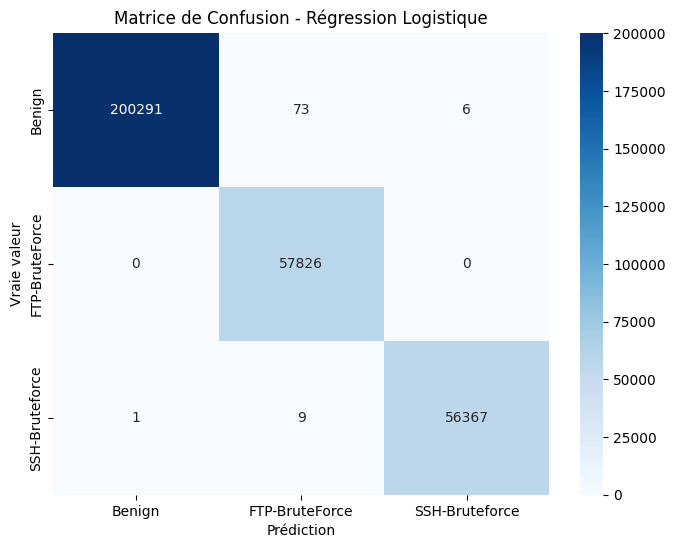

In [97]:
# On vérifie que la variable 'cm_lr' (calculée à l'étape 8) existe
if 'cm_lr' in locals() and 'encoder' in locals():

    print("--- Visualisation Modèle 1 : Matrice de Confusion (Régression Logistique) ---")

    # 5. Visualiser la Matrice de Confusion
    plt.figure(figsize=(8, 6)) # Ajuste la taille pour 3 classes
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie valeur')
    plt.title('Matrice de Confusion - Régression Logistique')
    plt.savefig('confusion_matrix_logistic.png') # Sauvegarde l'image
    plt.show()

else:
    print("Erreur : La variable 'cm_lr' (matrice de confusion) ou 'encoder' n'existe pas.")
    print("Veuillez d'abord exécuter la cellule d'évaluation (Étape 8).")

## 9. Modélisation (Modèle 2 : Random Forest)

Nous entraînons maintenant un second modèle, le **Random Forest Classifier**. C'est un modèle d'ensemble basé sur plusieurs arbres de décision, souvent plus performant que la Régression Logistique sur des données complexes et potentiellement non-linéaires.

In [98]:
from sklearn.ensemble import RandomForestClassifier

In [99]:
if 'X_train_scaled' in locals() and 'Y_train' in locals():
    # Créer le modèle RandomForest
    # n_estimators=100 : utilise 100 arbres
    # random_state=42 : pour la reproductibilité
    # n_jobs=-1 : utilise tous les cœurs CPU pour accélérer
    model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    print("--- Entraînement Modèle 2 : Random Forest ---")
    print("Modèle RandomForest créé.")

    # Entraîner le modèle
    print("Début de l'entraînement...")
    model_rf.fit(X_train_scaled, Y_train)
    print("Entraînement RandomForest terminé !")

else:
    print("Erreur : Les variables X_train_scaled et/ou y_train n'existent pas.")

--- Entraînement Modèle 2 : Random Forest ---
Modèle RandomForest créé.
Début de l'entraînement...
Entraînement RandomForest terminé !


## 10. Évaluation (Modèle 2 : Calcul des Métriques Random Forest)

Évaluation du modèle Random Forest sur l'ensemble de test. Nous calculons les mêmes métriques (Accuracy, Rapport de Classification, Matrice de Confusion) pour pouvoir comparer objectivement sa performance avec celle de la Régression Logistique.

In [100]:
# (Assure-toi que model_rf, X_test_scaled, y_test, et encoder existent)

if 'model_rf' in locals() and 'X_test_scaled' in locals() and 'Y_test' in locals() and 'encoder' in locals():

    print("--- Évaluation Modèle 2 : Random Forest (Calculs) ---")

    # 1. Faire les prédictions
    print("Prédiction sur les données de test...")
    Y_pred_rf = model_rf.predict(X_test_scaled)
    print("Prédictions terminées.")

    # 2. Calculer l'Accuracy
    accuracy_rf = accuracy_score(Y_test, Y_pred_rf)
    print(f"\nAccuracy (Précision Globale) : {accuracy_rf * 100:.2f}%")

    # 3. Afficher le Rapport de Classification
    print("\nRapport de Classification :")
    print(classification_report(Y_test, Y_pred_rf, target_names=encoder.classes_, zero_division=0))

    # 4. Calculer et Afficher la Matrice de Confusion (brute)
    print("\nMatrice de Confusion (Données brutes) :")
    cm_rf = confusion_matrix(Y_test, Y_pred_rf)
    print(cm_rf)

else:
    print("Erreur : Assurez-vous que 'model_rf', 'X_test_scaled', 'y_test' et 'encoder' existent.")

--- Évaluation Modèle 2 : Random Forest (Calculs) ---
Prédiction sur les données de test...
Prédictions terminées.

Accuracy (Précision Globale) : 100.00%

Rapport de Classification :
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    200370
FTP-BruteForce       1.00      1.00      1.00     57826
SSH-Bruteforce       1.00      1.00      1.00     56377

      accuracy                           1.00    314573
     macro avg       1.00      1.00      1.00    314573
  weighted avg       1.00      1.00      1.00    314573


Matrice de Confusion (Données brutes) :
[[200370      0      0]
 [     0  57826      0]
 [     0      9  56368]]


## 11. Visualisation (Modèle 2 : Matrice de Confusion Random Forest)

Visualisation de la performance du Random Forest à l'aide d'une heatmap Seaborn pour interpréter facilement les résultats de sa matrice de confusion.

--- Visualisation Modèle 2 : Matrice de Confusion (Random Forest) ---


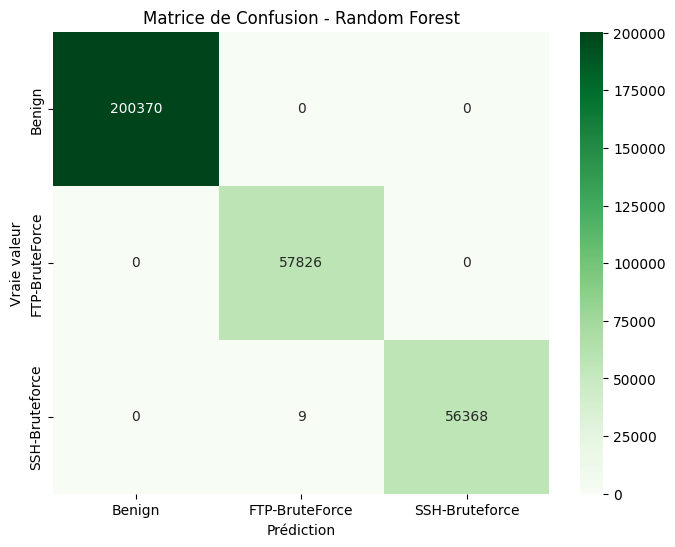

In [101]:
# On vérifie que la variable 'cm_rf' (calculée à l'étape 11) existe
if 'cm_rf' in locals() and 'encoder' in locals():

    print("--- Visualisation Modèle 2 : Matrice de Confusion (Random Forest) ---")

    # Visualiser la Matrice de Confusion
    plt.figure(figsize=(8, 6)) # Ajuste la taille
    # Utilisation d'une autre palette de couleurs (Greens) pour distinguer
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie valeur')
    plt.title('Matrice de Confusion - Random Forest')
    plt.savefig('confusion_matrix_rf.png') # Sauvegarde l'image
    plt.show()

else:
    print("Erreur : La variable 'cm_rf' (matrice de confusion RF) ou 'encoder' n'existe pas.")
    print("Veuillez d'abord exécuter la cellule d'évaluation du Random Forest (Étape 11).")



## 12. Comparaison des Modèles et Conclusion

Nous avons entraîné et évalué deux modèles de classification sur ce dataset de trafic réseau (`02-14-2018.csv`) pour détecter les attaques Brute Force (FTP et SSH).

1.  **Régression Logistique** (Modèle Linéaire Simple)
2.  **Random Forest Classifier** (Modèle d'Ensemble Basé sur des Arbres)

**Tableau Récapitulatif des Performances (basé sur les sorties du code) :**

| Modèle | Accuracy Globale | Faux Négatifs (Attaques -> "Bénin") | Faux Positifs ("Bénin" -> Attaque) | Erreurs inter-attaques |
| :--- | :--- | :--- | :--- | :--- |
| **Régression Logistique** | 99,97% | **1** (1 SSH classé Bénin) | **79** (73 Bénin -> FTP, 6 Bénin -> SSH) | 9 (SSH classé FTP) |
| **Random Forest** | **100,00%** (arrondi) | **0** | **0** | 9 (SSH classé FTP) |

**Analyse Comparative :**

* **Performance Exceptionnelle :** Les deux modèles ont atteint une performance quasi parfaite. L'**Accuracy atteint 100,00%** (arrondi) pour le Random Forest et 99,97% pour la Régression Logistique.
* **Minimisation des Erreurs Critiques (Faux Négatifs) :** C'est la victoire la plus importante. Le **Random Forest n'a manqué aucune attaque** (0 Faux Négatif). La Régression Logistique n'en a manqué qu'une seule, ce qui reste un score excellent.
* **Réduction des Fausses Alertes (Faux Positifs) :** Le Random Forest a également **éliminé toutes les fausses alertes**, ne classant aucun trafic bénin comme une attaque (0 Faux Positif). La Régression Logistique en a généré 79.
* **Erreurs mineures :** Fait intéressant, les deux modèles ont commis exactement la même erreur mineure : 9 attaques SSH ont été confondues avec des attaques FTP. En sécurité, cela reste une détection réussie (l'alerte est levée), seule la classification de l'attaque est imprécise.

**Conclusion Finale :**

Pour ce jeu de données spécifique (`02-14-2018.csv`), le **Random Forest Classifier atteint une performance parfaite** en termes de détection d'intrusion. Il surpasse nettement la Régression Logistique en éliminant à la fois les Faux Négatifs (attaques manquées) et les Faux Positifs (fausses alertes).

Dans un contexte de sécurité où manquer une seule attaque (un Faux Négatif) est le risque principal, la performance irréprochable du **Random Forest** en fait le **choix optimal**.

Ce projet illustre la puissance du Machine Learning pour la détection d'intrusions. La performance parfaite suggère que les attaques Brute Force dans ce fichier particulier présentent des signatures de flux réseau très distinctes et facilement identifiables par le modèle d'ensemble.

